In [1]:
import sys, warnings, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Librosa:", librosa.__version__)


Python: /home/adminbum/ntqai/.venv/bin/python
NumPy: 2.5.3
Pandas: 3.0.6
Librosa: 1.0.0


/home/adminbum/ntqai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_PATH = Path("/mnt/d/Data/VNTM3")
AUDIT_CSV = DATASET_PATH / "_audit" / "audio_audit.csv"

OUT = DATASET_PATH / "_stft30_v1"
FEATURE_DIR = OUT / "features"
REPORT_DIR = OUT / "reports"
PREVIEW_DIR = OUT / "previews"

for p in [OUT, FEATURE_DIR, REPORT_DIR, PREVIEW_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SR = 22050
DURATION = 30.0
N_SAMPLES = int(SR * DURATION)

N_FFT = 2048
HOP_LENGTH = 512
WIN_LENGTH = 2048
TOP_DB = 80.0

TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42

print("Output:", OUT)
print("Samples/file:", N_SAMPLES)
print("Expected STFT frequency bins:", N_FFT // 2 + 1)


Output: /mnt/d/Data/VNTM3/_stft30_v1
Samples/file: 661500
Expected STFT frequency bins: 1025


In [3]:
df = pd.read_csv(AUDIT_CSV)
df = df[df["status"] == "OK"].copy()

df["exact_duplicate_removed"] = False
df["exact_duplicate_of"] = ""

for sha, part in df[df["sha256"].notna()].groupby("sha256"):
    if len(part) <= 1:
        continue

    part = part.sort_values(["label", "filename"])
    keeper = part.iloc[0]["relative_path"]

    for idx in part.index[1:]:
        df.loc[idx, "exact_duplicate_removed"] = True
        df.loc[idx, "exact_duplicate_of"] = keeper

removed = df[df["exact_duplicate_removed"]].copy()
clean = df[~df["exact_duplicate_removed"]].copy().reset_index(drop=True)

print("Audit OK files:", len(df))
print("Exact duplicate copies removed:", len(removed))
print("Clean files:", len(clean))

display(clean.groupby("label").size().rename("files").reset_index())

removed.to_csv(
    REPORT_DIR / "exact_duplicates_removed.csv",
    index=False, encoding="utf-8-sig"
)


Audit OK files: 2499
Exact duplicate copies removed: 4
Clean files: 2495


,label,files
0,cailuong,500
1,catru,496
2,chauvan,499
3,cheo,500
4,hatxam,500


In [4]:
train_df, temp_df = train_test_split(
    clean,
    test_size=(VALID_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=clean["label"],
    shuffle=True
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=TEST_RATIO / (VALID_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=temp_df["label"],
    shuffle=True
)

train_df = train_df.copy()
valid_df = valid_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
valid_df["split"] = "valid"
test_df["split"] = "test"

manifest = pd.concat(
    [train_df, valid_df, test_df],
    ignore_index=True
)

manifest = manifest.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Total:", len(manifest))
display(
    manifest.groupby(["label", "split"])
    .size()
    .unstack(fill_value=0)
)

print("\nTotals:")
display(manifest["split"].value_counts())


Total: 2495


split,test,train,valid
label,,,
cailuong,75,350,75
catru,75,347,74
chauvan,75,349,75
cheo,75,350,75
hatxam,75,350,75



Totals:


split
train    1746
test      375
valid     374
Name: count, dtype: int64

In [5]:
assert len(manifest) == len(clean)
assert not manifest["relative_path"].duplicated().any()


sha_split_count = (
    manifest[manifest["sha256"].notna()]
    .groupby("sha256")["split"]
    .nunique()
)
assert (sha_split_count <= 1).all()

assert set(manifest["split"]) == {"train", "valid", "test"}

print("✅ All clean files assigned exactly once")
print("✅ No exact SHA-256 duplicate crosses splits")


✅ All clean files assigned exactly once
✅ No exact SHA-256 duplicate crosses splits


In [6]:
def load_fixed_audio(path):
    y, _ = librosa.load(path, sr=SR, mono=True)

    original_samples = len(y)

    if len(y) > N_SAMPLES:
        y = y[:N_SAMPLES]
        action = "cropped"
    elif len(y) < N_SAMPLES:
        y = np.pad(y, (0, N_SAMPLES - len(y)))
        action = "padded"
    else:
        action = "exact"

    return y.astype(np.float32), original_samples, action


def log_power_stft(y):
    D = librosa.stft(
        y,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann",
        center=True
    )

    power = np.abs(D) ** 2

    db = librosa.power_to_db(
        power,
        ref=np.max,
        top_db=TOP_DB
    )

    
    x = (db + TOP_DB) / TOP_DB
    x = np.clip(x, 0.0, 1.0)

    return x.astype(np.float32)


In [7]:
sample = manifest.iloc[0]
y, original_samples, action = load_fixed_audio(sample["path"])
X = log_power_stft(y)

print("File:", sample["relative_path"])
print("Label:", sample["label"])
print("Audio shape:", y.shape)
print("Length action:", action)
print("STFT shape:", X.shape)
print("Range:", float(X.min()), "→", float(X.max()))

assert y.shape == (N_SAMPLES,)
assert X.shape[0] == N_FFT // 2 + 1
assert X.dtype == np.float32
assert X.min() >= 0.0 and X.max() <= 1.0


File: cheo/Cheo.265.wav
Label: cheo
Audio shape: (661500,)
Length action: exact
STFT shape: (1025, 1292)
Range: 0.0 → 1.0


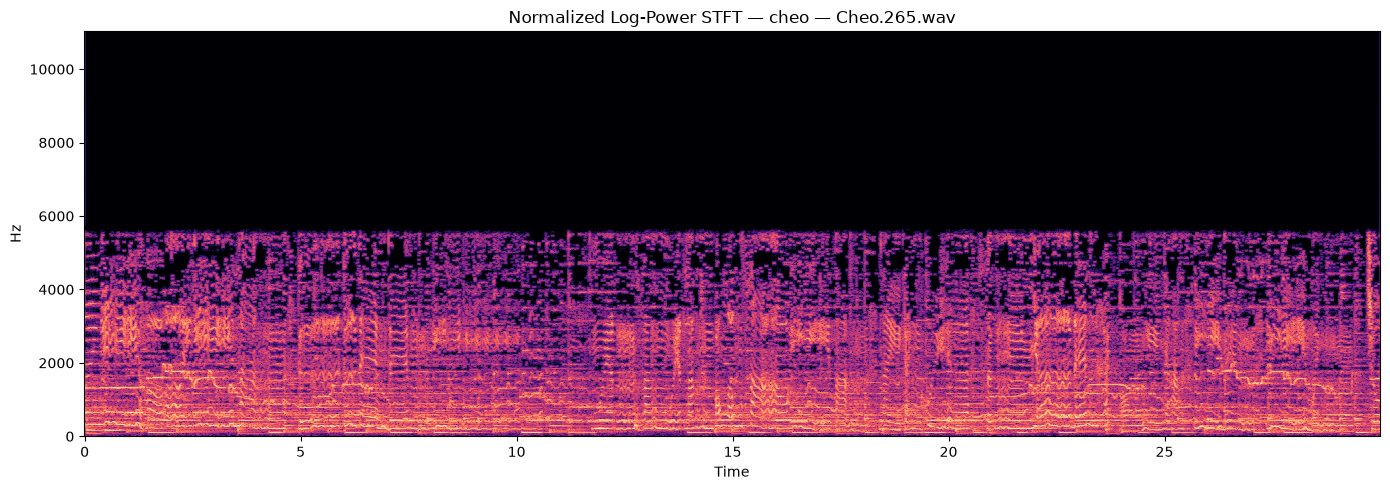

In [8]:
plt.figure(figsize=(14, 5))
librosa.display.specshow(
    X,
    sr=SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="linear"
)
plt.title(f"Normalized Log-Power STFT — {sample['label']} — {sample['filename']}")
plt.tight_layout()
plt.show()


In [9]:
records = []
errors = []

for row in tqdm(
    manifest.itertuples(index=False),
    total=len(manifest),
    desc="Extracting 30s STFT"
):
    try:
        out_dir = FEATURE_DIR / row.split / row.label
        out_dir.mkdir(parents=True, exist_ok=True)

        stem = Path(row.filename).stem
        out_path = out_dir / f"{stem}.npy"

        if out_path.exists():
            arr = np.load(out_path, mmap_mode="r")

            if (
                arr.ndim == 2 and
                arr.shape[0] == N_FFT // 2 + 1 and
                arr.dtype == np.float32
            ):
                action = "cached"
                shape = tuple(arr.shape)
            else:
                out_path.unlink()
                y, original_samples, action = load_fixed_audio(row.path)
                arr = log_power_stft(y)
                np.save(out_path, arr)
                shape = tuple(arr.shape)
        else:
            y, original_samples, action = load_fixed_audio(row.path)
            arr = log_power_stft(y)
            np.save(out_path, arr)
            shape = tuple(arr.shape)

        records.append({
            "split": row.split,
            "label": row.label,
            "filename": row.filename,
            "relative_path": row.relative_path,
            "audio_path": row.path,
            "feature_path": str(out_path),
            "stft_freq_bins": shape[0],
            "stft_time_frames": shape[1],
            "length_action": action
        })

    except Exception as e:
        errors.append({
            "split": row.split,
            "label": row.label,
            "filename": row.filename,
            "relative_path": row.relative_path,
            "error": repr(e)
        })

feature_manifest = pd.DataFrame(records)
errors_df = pd.DataFrame(errors)

print("Features OK:", len(feature_manifest))
print("Errors:", len(errors_df))

if len(errors_df):
    display(errors_df.head(50))


Extracting 30s STFT: 100%|██████████| 2495/2495 [02:13<00:00, 18.73it/s]

Features OK: 2495
Errors: 0


In [10]:
if len(errors_df) == 0:
    assert len(feature_manifest) == len(manifest)

shape_counts = (
    feature_manifest
    .groupby(["stft_freq_bins", "stft_time_frames"])
    .size()
    .rename("files")
    .reset_index()
)

print("Feature shapes:")
display(shape_counts)

print("\nFeatures by split/class:")
display(
    feature_manifest.groupby(["label", "split"])
    .size()
    .unstack(fill_value=0)
)

assert feature_manifest["stft_freq_bins"].nunique() == 1
assert feature_manifest["stft_time_frames"].nunique() == 1

print("✅ All extracted STFT matrices have identical shape")


Feature shapes:


,stft_freq_bins,stft_time_frames,files
0,1025,1292,2495



Features by split/class:


split,test,train,valid
label,,,
cailuong,75,350,75
catru,75,347,74
chauvan,75,349,75
cheo,75,350,75
hatxam,75,350,75


✅ All extracted STFT matrices have identical shape


In [11]:
split_manifest_cols = [
    "split", "label", "filename",
    "relative_path", "path",
    "duration_sec", "sample_rate",
    "channels", "rms", "sha256"
]

split_manifest = manifest[split_manifest_cols].copy()

split_manifest.to_csv(
    REPORT_DIR / "split_manifest.csv",
    index=False, encoding="utf-8-sig"
)

for split_name in ["train", "valid", "test"]:
    split_manifest[
        split_manifest["split"] == split_name
    ].to_csv(
        REPORT_DIR / f"{split_name}.csv",
        index=False, encoding="utf-8-sig"
    )

feature_manifest.to_csv(
    REPORT_DIR / "stft_feature_manifest.csv",
    index=False, encoding="utf-8-sig"
)

errors_df.to_csv(
    REPORT_DIR / "stft_errors.csv",
    index=False, encoding="utf-8-sig"
)

split_summary = (
    split_manifest.groupby(["split","label"])
    .size()
    .rename("n_files")
    .reset_index()
)

split_summary.to_csv(
    REPORT_DIR / "split_summary.csv",
    index=False, encoding="utf-8-sig"
)

print("Saved:", REPORT_DIR)
for p in sorted(REPORT_DIR.glob("*.csv")):
    print(" -", p.name)


Saved: /mnt/d/Data/VNTM3/_stft30_v1/reports
 - exact_duplicates_removed.csv
 - split_manifest.csv
 - split_summary.csv
 - stft_errors.csv
 - stft_feature_manifest.csv
 - test.csv
 - train.csv
 - valid.csv


In [12]:
for label in sorted(feature_manifest["label"].unique()):
    row = feature_manifest[
        feature_manifest["label"] == label
    ].iloc[0]

    x = np.load(row["feature_path"])

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        x,
        sr=SR,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="linear"
    )
    plt.title(f"{label} — 30s Log-Power STFT")
    plt.tight_layout()

    safe_label = str(label).replace(" ", "_")
    plt.savefig(
        PREVIEW_DIR / f"{safe_label}_stft.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.close()

print("Preview images:", PREVIEW_DIR)


Preview images: /mnt/d/Data/VNTM3/_stft30_v1/previews


In [13]:
print("=" * 72)
print("VNTM3 — STFT30 V1")
print("=" * 72)

print("Clean audio files :", len(split_manifest))
print("STFT files        :", len(feature_manifest))
print("Extraction errors :", len(errors_df))

if len(feature_manifest):
    shape = (
        int(feature_manifest.iloc[0]["stft_freq_bins"]),
        int(feature_manifest.iloc[0]["stft_time_frames"])
    )
    print("STFT shape/file   :", shape)

print("\nSPLIT:")
display(
    split_manifest.groupby(["label","split"])
    .size()
    .unstack(fill_value=0)
)

print("\nOutput:", OUT)
print("\nNEXT: send split_summary.csv + stft_errors.csv (and final cell output) to ChatGPT.")


VNTM3 — STFT30 V1
Clean audio files : 2495
STFT files        : 2495
Extraction errors : 0
STFT shape/file   : (1025, 1292)

SPLIT:


split,test,train,valid
label,,,
cailuong,75,350,75
catru,75,347,74
chauvan,75,349,75
cheo,75,350,75
hatxam,75,350,75



Output: /mnt/d/Data/VNTM3/_stft30_v1

NEXT: send split_summary.csv + stft_errors.csv (and final cell output) to ChatGPT.
